<a href="https://colab.research.google.com/github/Lujain-A12/lap1/blob/main/AI342Lab1_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AI342-F1/Lab-Tutoral/blob/main/AI342Lab1.ipynb)

# Lab 1: Introduction to Digital Images and Image Processing with Python
**Course:** AI342 Image Processing  
**University:** Taibah University  
**College:** Computer Science and Engineering  
**Department:** AI & DS
---
### Learning Objectives:
* Represent a digital image as a numerical array.
* Understand pixels, spatial resolution, and grey level intensity.
* Load, display, and inspect images in Python.
* Apply simple low-level image processing operations.
* Relate practical operations to the image processing pipeline introduced in Chapter 1

## 1. Environment Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2



## 2. What is a digital image in practice?
In the lecture, a digital image is defined as a two dimensional function $f(x,y)$ where the value at each coordinate represents intensity. In practice, this function is stored as a matrix of numbers.

##**Exercise 2.1: Create a synthetic image**


In [2]:
image = np.zeros((8, 8))
print(image)



# --- Discussion Questions ---
# 1. What is the spatial resolution of this image? 8x8
# 2. What does each value represent? intensity

[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


##**Exercise 2.2: Visualise the image**

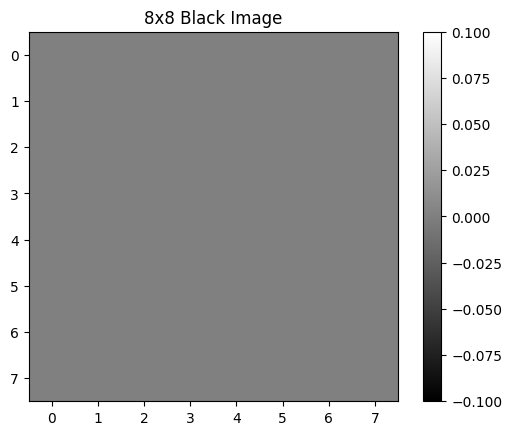

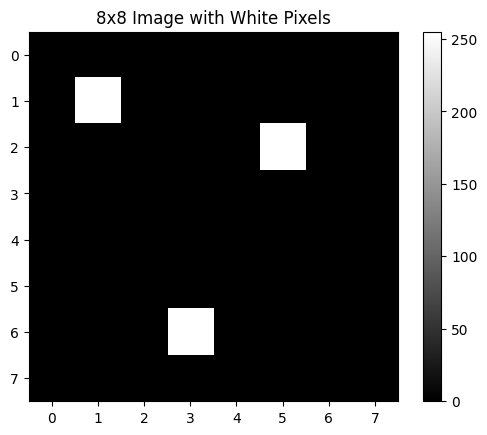

In [3]:
plt.imshow(image, cmap='gray')
plt.title("8x8 Black Image")
plt.colorbar()
plt.show()

# Task: Change some pixels to 255 (White) and re-visualize
# image[row, col] = 255
# WRITE YOUR CODE HERE:

image[1, 1] = 255
image[2, 5] = 255
image[6, 3] = 255

plt.imshow(image, cmap='gray')
plt.title("8x8 Image with White Pixels")
plt.colorbar()
plt.show()


## 3. Pixels and intensity values
Pixels are the smallest units of a digital image and hold quantised intensity values, as discussed in the slides on pixels and digitisation
## **Exercise 3.1: Modify individual pixels**


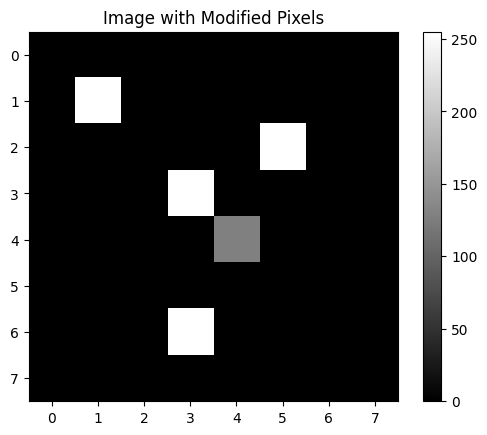

In [4]:
image[3, 3] = 255
image[4, 4] = 128

plt.imshow(image, cmap='gray')
plt.title("Image with Modified Pixels")
plt.colorbar()
plt.show()

#Questions
#1.	Which pixel is brighter and why? 255 (white)
#2.	How does quantisation affect visual appearance? Quantization uses discrete levels, so it loses fine brightness detail and can create visible bands.



## 4. Grey scale images
The course focuses primarily on grey scale images with one sample per pixel.
## **Exercise 4.1: Generate a gradient image**


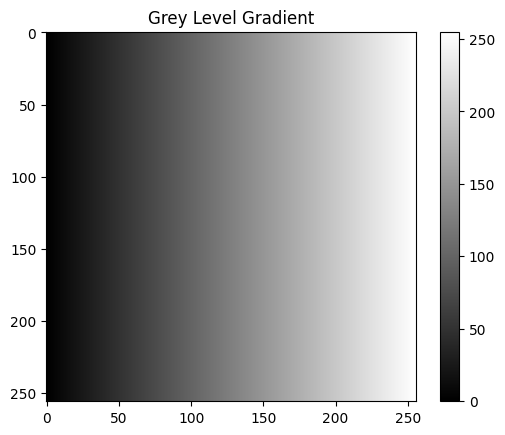

In [5]:
gradient = np.tile(np.linspace(0, 255, 256), (256, 1))

plt.imshow(gradient, cmap='gray')
plt.title("Grey Level Gradient")
plt.colorbar()
plt.show()

#Questions
#1.	How many grey levels are visible? 256
#2.	What data type is used to store the pixel values? float64



## 5. Image acquisition and representation
Image acquisition converts a physical scene into a digital image. In Python, loading an image is equivalent to acquiring an already digitised scene.
## **Exercise 5.1: Load and inspect an image**

(414, 620, 3)
uint8


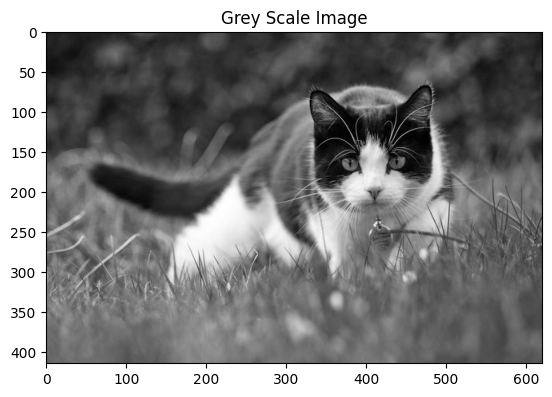

In [6]:
from matplotlib.image import imread

image = imread('/content/cat.jpg')
print(image.shape)
print(image.dtype)

gray = image.mean(axis=2)

plt.imshow(gray, cmap='gray')
plt.title("Grey Scale Image")
plt.show()


## 6. Low level image processing: image in, image out
Low level processing improves visual quality without extracting semantic meaning, as described in the lecture pipeline
## **Exercise 6.1: Image enhancement by contrast stretching**

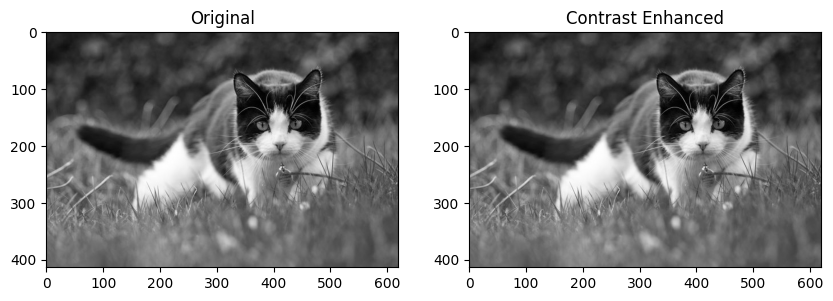

In [7]:
min_val = gray.min()
max_val = gray.max()

enhanced = (gray - min_val) / (max_val - min_val) * 255

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(enhanced, cmap='gray')

plt.title("Contrast Enhanced")
plt.show()

#Questions
#1.	Which image has better visibility of details? The contrast enhanced image shows more detail.
#2.	Is this enhancement subjective or objective? objective



## 7. Noise and image restoration
Noise removal is a core example of low level processing.

## **Exercise 7.1: Add artificial noise**

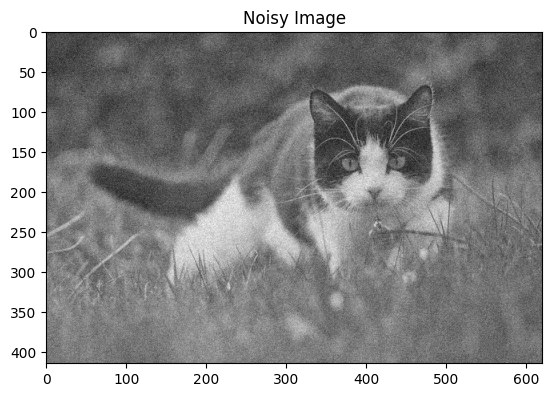

In [8]:

noise = np.random.normal(0, 20, gray.shape)
noisy = gray + noise

plt.imshow(noisy, cmap='gray')
plt.title("Noisy Image")
plt.show()


## **Exercise 7.2: Simple smoothing filter**

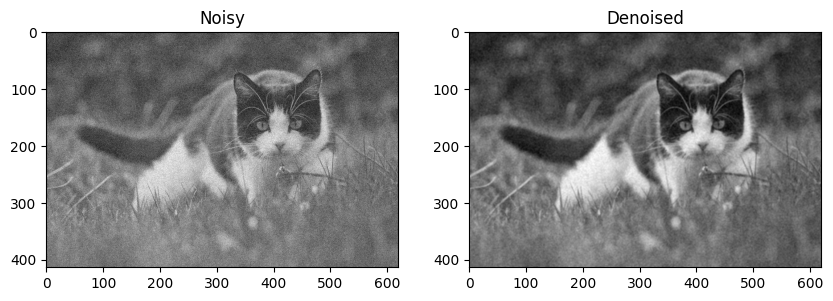

In [9]:
def mean_filter(img, k=3):
    pad = k // 2
    padded = np.pad(img, pad, mode='edge')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            output[i, j] = padded[i:i+k, j:j+k].mean()
    return output


denoised = mean_filter(noisy)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy")

plt.subplot(1,2,2)
plt.imshow(denoised, cmap='gray')
plt.title("Denoised")
plt.show()


## 8. From image processing to image analysis
The lecture distinguishes between low, mid, and high level processing.
## **Exercise 8.1: Simple threshold segmentation**

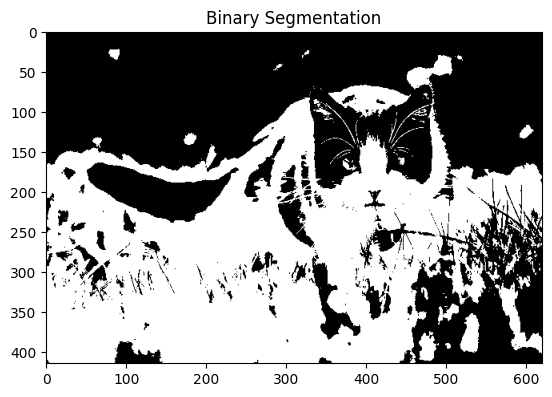

In [10]:
threshold = gray.mean()
binary = gray > threshold

plt.imshow(binary, cmap='gray')
plt.title("Binary Segmentation")
plt.show()

# Discussion:
# 1. Is this segmentation reliable? No
# 2. What information is lost when converting to binary? All grey‑level detail is lost, pixels are only black or white


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


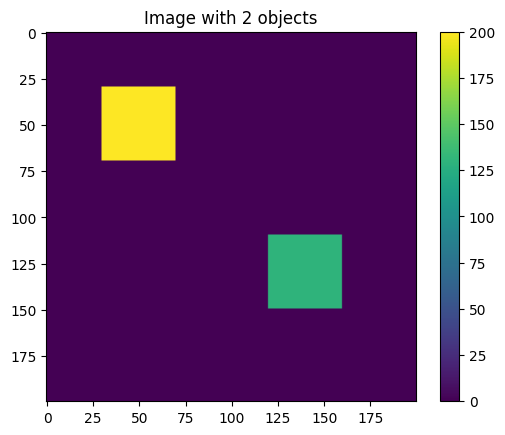

In [19]:
# Step 1: synthetic image with two objects
image = np.zeros((200, 200))
print(image)


# object 1
image[30:70, 30:70] = 200

# object 2
image[110:150, 120:160] = 130



plt.imshow(image)
plt.title("Image with 2 objects")
plt.colorbar()
plt.show()


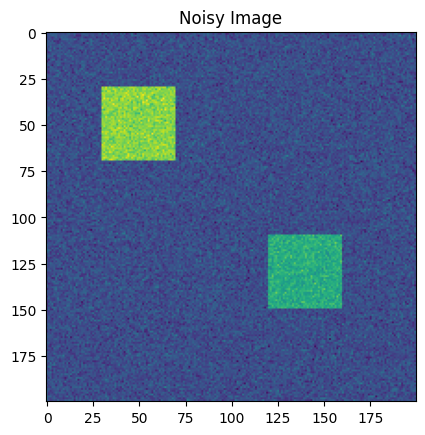

In [14]:
# Step 2: add noise
noise = np.random.normal(0, 20, image.shape)
noisy = image + noise

plt.imshow(noisy)
plt.title("Noisy Image")
plt.show()



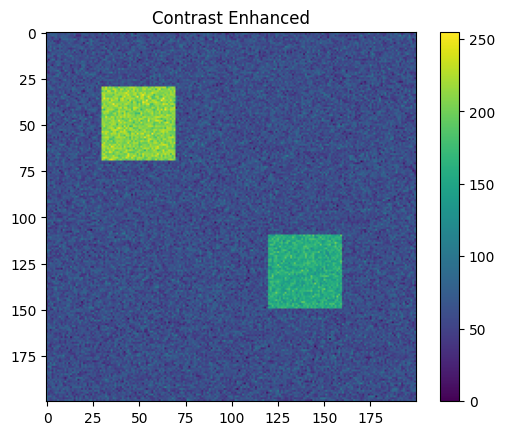

In [15]:
# step 3 : Apply enhancement
min_val = noisy.min()
max_val = noisy.max()

enhanced = (noisy - min_val) / (max_val - min_val) * 255

plt.imshow(enhanced)
plt.title("Contrast Enhanced")
plt.colorbar()
plt.show()


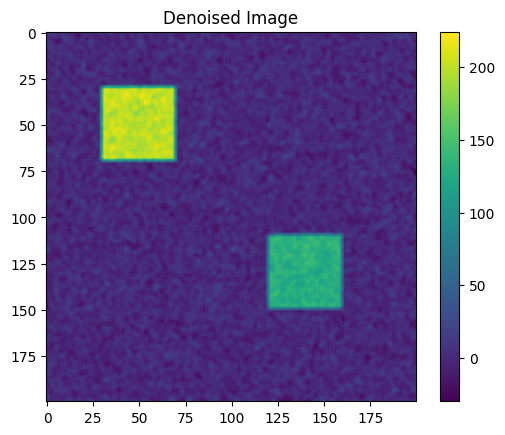

In [16]:
#step 3: Apply denoising
def mean_filter(img, k=3):
    pad = k // 2
    padded = np.pad(img, pad, mode='edge')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            output[i, j] = padded[i:i+k, j:j+k].mean()
    return output


denoised = mean_filter(noisy, k=3)

plt.imshow(denoised)
plt.title("Denoised Image")
plt.colorbar()
plt.show()


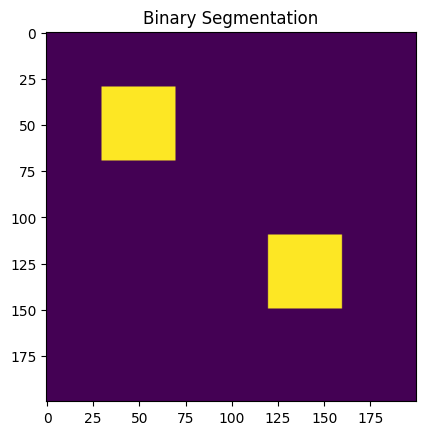

In [17]:
# Step 4: threshold segmentation
threshold = image.mean()
binary = image > threshold

plt.imshow(binary)
plt.title("Binary Segmentation")
plt.show()

MAPPING

In [ ]:
# 1- Creating the synthetic image → Image Acquisition (simulated scene to digital image).

# 2- Adding noise → models degradation during acquisition (sensor/channel).

# 3- Denoising → Image Restoration; contrast stretching → Image Enhancement (both low‑level, image in → image out).

# 4- Threshold segmentation → Segmentation, a mid‑level step separating objects from background

#**9. Mini project: connecting theory to practice**

**Task**

Using only NumPy and Matplotlib:

1.	Create a synthetic image containing at least two objects

2.	Add noise to the image

3.	Apply enhancement and denoising

4.	Segment the objects using a threshold

**Deliverables**

•	Code

•	Output images

•	Short explanation mapping each step to the image processing stages shown in the Chapter 1 pipeline diagram


***Note: Organize your project into logical steps using separate cells, include a Text Cell before each stage to explain your approach, and ensure all results are clearly visualized using titles and subplots***